In [1]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

iris = load_iris()
iris_scaled = StandardScaler().fit_transform(iris.data)

In [2]:
lda = LinearDiscriminantAnalysis(n_components=2)
lda.fit(iris_scaled, iris.target)
iris_lda = lda.transform(iris_scaled)
print(iris_lda.shape)

(150, 2)


<function matplotlib.pyplot.show(close=None, block=None)>

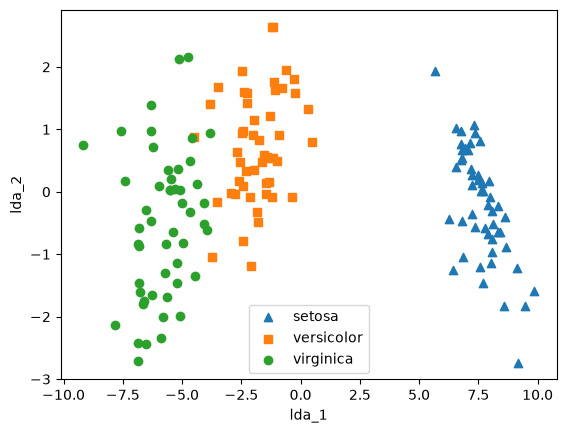

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

lda_cols = ['lda_1','lda_2']
df_lda = pd.DataFrame(iris_lda, columns=lda_cols)
df_lda['target'] = iris.target

markers = ['^','s','o']

for i, marker in enumerate(markers):
    x_data = df_lda[df_lda['target']==i]['lda_1']
    y_data = df_lda[df_lda['target']==i]['lda_2']
    plt.scatter(x_data,y_data,marker = marker, label = iris.target_names[i])

plt.legend()
plt.xlabel('lda_1')
plt.ylabel('lda_2')
plt.show

Text(0, 0.5, 'TSVD Comp 2')

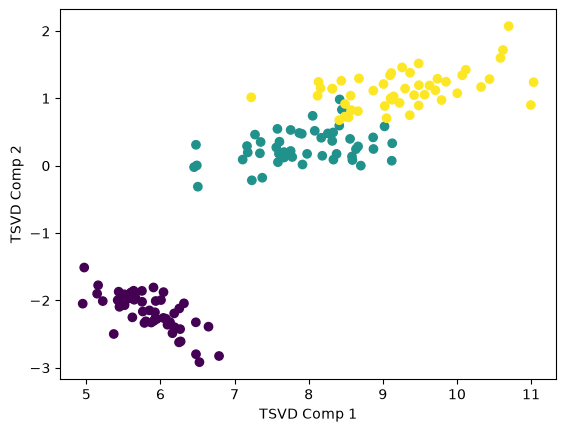

In [7]:
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

iris = load_iris()
iris_ftrs = iris.data

tsvd = TruncatedSVD(n_components=2)
tsvd.fit(iris_ftrs)
iris_tsvd = tsvd.transform(iris_ftrs)

plt.scatter(x = iris_tsvd[:,0], y = iris_tsvd[:,1], c= iris.target)
plt.xlabel('TSVD Comp 1')
plt.ylabel('TSVD Comp 2')

Text(0.5, 1.0, 'PCA')

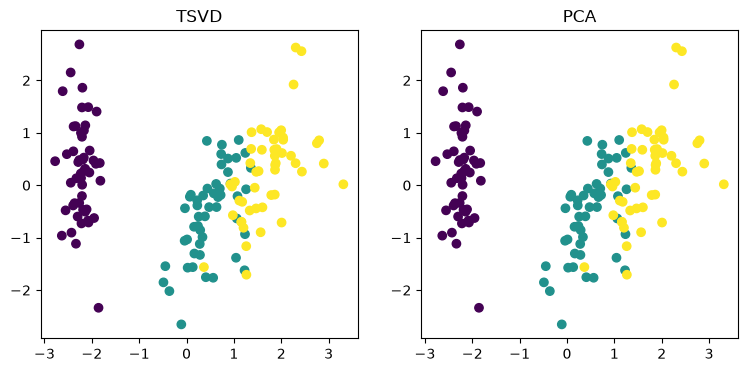

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
iris_scaled = scaler.fit_transform(iris_ftrs)

tsvd = TruncatedSVD(n_components=2)
tsvd.fit(iris_scaled)
iris_tsvd = tsvd.transform(iris_scaled)

pca = PCA(n_components= 2)
pca.fit(iris_scaled)
iris_pca = pca.transform(iris_scaled)

fig, (ax1,ax2) = plt.subplots(figsize=(9,4),ncols=2)
ax1.scatter(x=iris_tsvd[:,0], y = iris_tsvd[:,1],c=iris.target)
ax2.scatter(x=iris_pca[:,0], y = iris_pca[:,1],c=iris.target)
ax1.set_title('TSVD')
ax2.set_title('PCA')

In [11]:
print((iris_pca - iris_tsvd).mean())
print((pca.components_ - tsvd.components_).mean())

2.346433232898922e-15
7.632783294297951e-17


c:\Users\KDS23\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


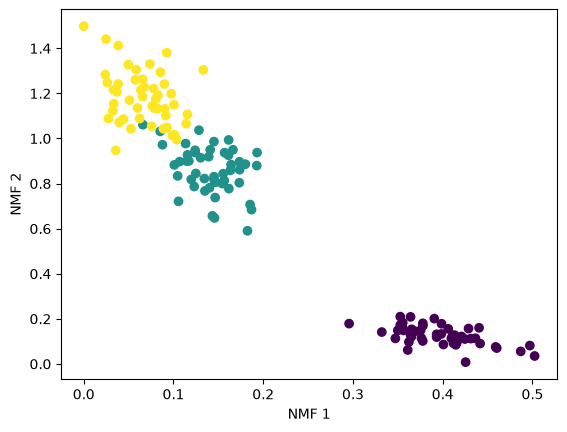

In [13]:
from sklearn.decomposition import NMF

iris = load_iris()
iris_fts = iris.data
nmf = NMF(n_components = 2)
nmf.fit(iris_ftrs)
iris_nmf = nmf.transform(iris_ftrs)
plt.scatter(x=iris_nmf[:,0],y=iris_nmf[:,1],c=iris.target)
plt.xlabel('NMF 1')
plt.ylabel('NMF 2')
plt.show()